# Fraud Detection - Stacking Ensemble Inference Notebook

This notebook loads the trained fraud detection stacking ensemble artifacts and runs inference on new credit card transactions.

The ensemble contains five base models:

1. Random Forest
2. LightGBM
3. CatBoost
4. XGBoost
5. Neural Network

Their probability outputs are combined by a Logistic Regression meta-model.

The production threshold is loaded from `production_manifest.json`.

# Initial Setup

## Install and Import Libraries

In [1]:
%%capture
!pip install -q ipython-autotime
!pip install -q gdown
!pip install -q kagglehub joblib pandas numpy scikit-learn xgboost lightgbm catboost tensorflow
%load_ext autotime

time: 480 µs (started: 2026-06-13 07:52:29 +00:00)


In [2]:
import os
import json
import joblib
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt


import gdown
import kagglehub

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    ConfusionMatrixDisplay
)

from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from tensorflow import keras

time: 12.1 s (started: 2026-06-13 07:52:29 +00:00)


## Global Parameters

In [3]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

LABELS = ["Legitimate", "Fraud"]

META_FEATURES =[
    "rf_prob",
    "lgbm_prob",
    "cat_prob",
    "xgb_prob",
    "nn_prob"
]

DEFAULT_PRODUCTION_THRESHOLD = 0.5
BUSINESS_THRESHOLD = 0.65

print("Meta feature order:")
print(META_FEATURES)

print("Default production threshold:", DEFAULT_PRODUCTION_THRESHOLD)

Meta feature order:
['rf_prob', 'lgbm_prob', 'cat_prob', 'xgb_prob', 'nn_prob']
Default production threshold: 0.5
time: 6.02 ms (started: 2026-06-13 07:52:41 +00:00)


## Download Saved Artifacts with gdown

The notebook expects these files:

- preprocessing_artifacts.joblib
- neural_network_scaler.joblib
- random_forest.joblib
- lightgbm.joblib
- catboost.cbm
- xgboost.json
- best_nn.keras
- stacking_meta_model.joblib
- production_manifest.json

In [ ]:
ARTIFACT_DIR = "/content/fraud_stacking_artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

artifact_file_ids = {
    "preprocessing_artifacts.joblib": "12wDMl5MU6kNcLoFXTKw3Ex51853OzdCZ",
    "neural_network_scaler.joblib": "1Zl-mkEn8j8Pn2MQxsx-kzQ_Qz19bP_cx",
    "random_forest.joblib": "12nMtybkXtj6TGg_t_9Kt-j7VmVspnVbC",
    "lightgbm.joblib": "13U9az2nwzCvdLc_kmS1rxcupMoTGTJfc",
    "catboost.cbm": "1c8QLXfW0rp3H3M9dyS4obI43oxPMjrAn",
    "xgboost.json": "1AerxFemFwZQita5ni0IQK4eJ19vBN7n_",
    "best_nn.keras": "1j4qdKHssM4vrQ5uZEedCDCQZzWus4tsk",
    "stacking_meta_model.joblib": "1Ma9O_GvRM4sgw8u4iQkfSI5vEk8zhsoC",
    "production_manifest.json": "1D4bM_XPHtceh_tKe-VG3RD847oq5snMj",
}

artifact_paths = {}

for filename, file_id in artifact_file_ids.items():
    output_path = os.path.join(ARTIFACT_DIR, filename)
    artifact_paths[filename] = output_path
    
    url = f"https://drive.google.com/uc?id={file_id}"
    gdown.download(url, output_path, quiet=False)

print("\nArtifact paths:")
for name, path in artifact_paths.items():
    print(name, "->", path)

Downloading...
From: https://drive.google.com/uc?id=12wDMl5MU6kNcLoFXTKw3Ex51853OzdCZ
To: /content/fraud_stacking_artifacts/preprocessing_artifacts.joblib
100%|██████████| 33.3k/33.3k [00:00<00:00, 53.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Zl-mkEn8j8Pn2MQxsx-kzQ_Qz19bP_cx
To: /content/fraud_stacking_artifacts/neural_network_scaler.joblib
100%|██████████| 1.40k/1.40k [00:00<00:00, 1.35MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=12nMtybkXtj6TGg_t_9Kt-j7VmVspnVbC
From (redirected): https://drive.google.com/uc?id=12nMtybkXtj6TGg_t_9Kt-j7VmVspnVbC&confirm=t&uuid=5c382cb9-30cc-4248-8ac3-0a7233782693
To: /content/fraud_stacking_artifacts/random_forest.joblib
100%|██████████| 125M/125M [00:01<00:00, 86.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=13U9az2nwzCvdLc_kmS1rxcupMoTGTJfc
To: /content/fraud_stacking_artifacts/lightgbm.joblib
100%|██████████| 2.48M/2.48M [00:00<00:00, 33.4MB/s]
Downloading...
From: https://drive.google.com/uc?i


Artifact paths:
preprocessing_artifacts.joblib -> /content/fraud_stacking_artifacts/preprocessing_artifacts.joblib
neural_network_scaler.joblib -> /content/fraud_stacking_artifacts/neural_network_scaler.joblib
random_forest.joblib -> /content/fraud_stacking_artifacts/random_forest.joblib
lightgbm.joblib -> /content/fraud_stacking_artifacts/lightgbm.joblib
catboost.cbm -> /content/fraud_stacking_artifacts/catboost.cbm
xgboost.json -> /content/fraud_stacking_artifacts/xgboost.json
best_nn.keras -> /content/fraud_stacking_artifacts/best_nn.keras
stacking_meta_model.joblib -> /content/fraud_stacking_artifacts/stacking_meta_model.joblib
production_manifest.json -> /content/fraud_stacking_artifacts/production_manifest.json
time: 16.8 s (started: 2026-06-13 07:52:41 +00:00)


## Load Saved Artifacts


In [5]:
preprocessing_artifacts = joblib.load(
    artifact_paths["preprocessing_artifacts.joblib"]
)

neural_network_scaler = joblib.load(
    artifact_paths["neural_network_scaler.joblib"]
)

rf_model = joblib.load(
    artifact_paths["random_forest.joblib"]
)

lgbm_model = joblib.load(
    artifact_paths["lightgbm.joblib"]
)

meta_model = joblib.load(
    artifact_paths["stacking_meta_model.joblib"]
)

cat_model = CatBoostClassifier()
cat_model.load_model(
    artifact_paths["catboost.cbm"]
)

xgb_model = XGBClassifier()
xgb_model.load_model(
    artifact_paths["xgboost.json"]
)

nn_model = keras.models.load_model(
    artifact_paths["best_nn.keras"]
)

with open(artifact_paths["production_manifest.json"], "r") as f:
    production_manifest = json.load(f)

print("All artifacts loaded successfully.")

All artifacts loaded successfully.
time: 8.7 s (started: 2026-06-13 07:52:58 +00:00)


## Inspect Manifest

The manifest is our production map.

It tells us:

- Which meta-features the stacking model expects
- What threshold should be used in production
- Which artifacts belong to this model version

In [6]:
print(json.dumps(production_manifest, indent=4))

manifest_meta_features = production_manifest.get("meta_features", META_FEATURES)

production_threshold = BUSINESS_THRESHOLD

print("Business threshold selected:", production_threshold)
print("Reason: maximize fraud recall while accepting false alerts.")

print("\nMeta features from manifest:")
print(manifest_meta_features)

print("\nProduction threshold:")
print(production_threshold)

assert manifest_meta_features == META_FEATURES, "Meta feature order does not match training notebook!"

print("\nManifest check passed.")

{
    "saved_at": "2026-06-12T08:15:57.697976",
    "label_names": [
        "Legitimate",
        "Fraud"
    ],
    "meta_features": [
        "rf_prob",
        "lgbm_prob",
        "cat_prob",
        "xgb_prob",
        "nn_prob"
    ],
    "default_threshold": 0.5,
    "production_threshold": 0.9990673180660194,
    "models": {
        "random_forest": "/content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/models/random_forest.joblib",
        "lightgbm": "/content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/models/lightgbm.joblib",
        "catboost": "/content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/models/catboost.cbm",
        "xgboost": "/content/drive/MyDrive/Fraud_Detection_Project/Fraud_Detection_stacking/fraud_detection_oof_stacking_ensemble/models/xgboost.json",
        "neural_network": "/content/d

## Artifact Validation

This section validates the production environment before running inference.

Checks:

1. All required artifacts exist.
2. All models were loaded successfully.
3. Meta-feature order matches training.
4. Production threshold exists.
5. Preprocessing artifacts contain required fields.

If all checks pass, the notebook is ready for production inference.

In [7]:
required_artifacts = [
    "preprocessing_artifacts.joblib",
    "neural_network_scaler.joblib",
    "random_forest.joblib",
    "lightgbm.joblib",
    "catboost.cbm",
    "xgboost.json",
    "best_nn.keras",
    "stacking_meta_model.joblib",
    "production_manifest.json",
]

print("=" * 80)
print("VALIDATING ARTIFACTS")
print("=" * 80)

for artifact_name in required_artifacts:

    artifact_path = artifact_paths[artifact_name]

    assert os.path.exists(
        artifact_path
    ), f"Missing artifact: {artifact_name}"

    print(f" Found: {artifact_name}")

print("\nAll artifact files exist.")

VALIDATING ARTIFACTS
 Found: preprocessing_artifacts.joblib
 Found: neural_network_scaler.joblib
 Found: random_forest.joblib
 Found: lightgbm.joblib
 Found: catboost.cbm
 Found: xgboost.json
 Found: best_nn.keras
 Found: stacking_meta_model.joblib
 Found: production_manifest.json

All artifact files exist.
time: 1.37 ms (started: 2026-06-13 07:53:06 +00:00)


In [8]:
required_preprocessing_keys = [
    "encoder",
    "medians",
    "feature_columns",
    "categorical_columns",
]

for key in required_preprocessing_keys:

    assert key in preprocessing_artifacts, (
        f"Missing preprocessing key: {key}"
    )

print("Preprocessing artifact structure valid")

assert len(
    preprocessing_artifacts["feature_columns"]
) > 0

print(
    "Number of features:",
    len(preprocessing_artifacts["feature_columns"])
)

Preprocessing artifact structure valid
Number of features: 16
time: 707 µs (started: 2026-06-13 07:53:06 +00:00)


In [9]:
expected_meta_features = [
    "rf_prob",
    "lgbm_prob",
    "cat_prob",
    "xgb_prob",
    "nn_prob",
]

manifest_meta_features = production_manifest[
    "meta_features"
]

assert (
    manifest_meta_features
    == expected_meta_features
), "Meta-feature order mismatch"

print("Meta-feature order verified")

print(manifest_meta_features)

Meta-feature order verified
['rf_prob', 'lgbm_prob', 'cat_prob', 'xgb_prob', 'nn_prob']
time: 879 µs (started: 2026-06-13 07:53:06 +00:00)


In [10]:
expected_threshold = 0.9990673180660194

manifest_threshold = production_manifest[
    "production_threshold"
]

print(
    "Manifest threshold:",
    manifest_threshold
)

assert abs(
    manifest_threshold - expected_threshold
) < 1e-12

print("Production threshold verified")

Manifest threshold: 0.9990673180660194
Production threshold verified
time: 1.34 ms (started: 2026-06-13 07:53:06 +00:00)


In [11]:
assert rf_model is not None
assert lgbm_model is not None
assert cat_model is not None
assert xgb_model is not None
assert nn_model is not None
assert meta_model is not None

print("Random Forest loaded")
print("LightGBM loaded")
print("CatBoost loaded")
print("XGBoost loaded")
print("Neural Network loaded")
print("Meta Model loaded")

Random Forest loaded
LightGBM loaded
CatBoost loaded
XGBoost loaded
Neural Network loaded
Meta Model loaded
time: 934 µs (started: 2026-06-13 07:53:06 +00:00)


In [12]:
print("\n" + "=" * 80)
print("ALL VALIDATION CHECKS PASSED")
print("=" * 80)

print("Fraud Detection Stacking Ensemble is ready.")
print("Inference pipeline is production-ready.")


ALL VALIDATION CHECKS PASSED
Fraud Detection Stacking Ensemble is ready.
Inference pipeline is production-ready.
time: 513 µs (started: 2026-06-13 07:53:06 +00:00)


## Feature Engineering

This function must be identical to the training notebook.

We create:

- hour
- day_of_week
- month
- is_weekend
- age
- distance_km

Then we remove columns that were not used by the trained models.

In [13]:
def haversine_distance(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(
        np.radians,
        [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return 6371 * c


def add_features(df):
    df = df.copy()

    df = df.drop(
        columns=[col for col in ["Unnamed: 0"] if col in df.columns],
        errors="ignore"
    )

    if "trans_date_trans_time" in df.columns:
        trans_time = pd.to_datetime(
            df["trans_date_trans_time"],
            errors="coerce"
        )

        df["hour"] = trans_time.dt.hour
        df["day_of_week"] = trans_time.dt.dayofweek
        df["month"] = trans_time.dt.month
        df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
    else:
        trans_time = None

    if "dob" in df.columns:
        dob = pd.to_datetime(df["dob"], errors="coerce")

        if trans_time is not None:
            df["age"] = trans_time.dt.year - dob.dt.year
        else:
            df["age"] = 2020 - dob.dt.year

        df["age"] = df["age"].clip(lower=0, upper=100)

    required_distance_cols = {"lat", "long", "merch_lat", "merch_long"}

    if required_distance_cols.issubset(df.columns):
        df["distance_km"] = haversine_distance(
            df["lat"],
            df["long"],
            df["merch_lat"],
            df["merch_long"]
        )

    drop_cols = [
        "trans_date_trans_time",
        "cc_num",
        "first",
        "last",
        "street",
        "city",
        "state",
        "zip",
        "trans_num",
        "unix_time",
        "dob"
    ]

    df = df.drop(
        columns=[col for col in drop_cols if col in df.columns],
        errors="ignore"
    )

    return df

time: 1.93 ms (started: 2026-06-13 07:53:06 +00:00)


## Inference Preprocessing

This function prepares new raw transactions for prediction.

Steps:

1. Apply feature engineering.
2. Remove `is_fraud` if it exists.
3. Encode categorical columns with the saved encoder.
4. Align columns to the exact training feature order.
5. Fill missing values using saved training medians.

This is the production version of preprocessing.

In [14]:
def preprocess_for_inference(raw_df):
    df = raw_df.copy()

    df = add_features(df)

    if "is_fraud" in df.columns:
        df = df.drop(columns=["is_fraud"])

    encoder = preprocessing_artifacts["encoder"]
    medians = preprocessing_artifacts["medians"]
    feature_columns = preprocessing_artifacts["feature_columns"]
    categorical_columns = preprocessing_artifacts["categorical_columns"]

    missing_columns = [
        col for col in feature_columns
        if col not in df.columns
    ]

    for col in missing_columns:
        df[col] = np.nan

    if categorical_columns:
        for col in categorical_columns:
            if col not in df.columns:
                df[col] = "missing"

        df[categorical_columns] = encoder.transform(
            df[categorical_columns].astype(str)
        )

    df = df[feature_columns]
    df = df.fillna(medians)

    return df

time: 818 µs (started: 2026-06-13 07:53:06 +00:00)


## Stacking Prediction Function

This is the main production inference function.

For each transaction, it:

1. Applies the saved preprocessing.
2. Creates predictions from all five base models.
3. Builds the meta-feature table in the exact training order.
4. Sends the meta-features into the Logistic Regression meta-model.
5. Applies the production threshold.
6. Returns probabilities and final fraud labels.

In [15]:
def predict_fraud_stacking(raw_df, threshold=None):
    if threshold is None:
        threshold = production_threshold

    X_processed = preprocess_for_inference(raw_df)

    X_nn = neural_network_scaler.transform(X_processed)

    rf_prob = rf_model.predict_proba(X_processed)[:, 1]
    lgbm_prob = lgbm_model.predict_proba(X_processed)[:, 1]
    cat_prob = cat_model.predict_proba(X_processed)[:, 1]
    xgb_prob = xgb_model.predict_proba(X_processed)[:, 1]
    nn_prob = nn_model.predict(
        X_nn,
        batch_size=8192,
        verbose=0
    ).flatten()

    meta_features_df = pd.DataFrame({
        "rf_prob": rf_prob,
        "lgbm_prob": lgbm_prob,
        "cat_prob": cat_prob,
        "xgb_prob": xgb_prob,
        "nn_prob": nn_prob,
    })

    meta_features_df = meta_features_df[META_FEATURES]

    stacking_prob = meta_model.predict_proba(meta_features_df)[:, 1]

    final_prediction = (stacking_prob >= threshold).astype(int)
    result_df = meta_features_df.copy()
    result_df["stacking_prob"] = stacking_prob
    result_df["fraud_probability_percent"] = (
        result_df["stacking_prob"] * 100
    ).round(4)
    result_df["threshold_used"] = threshold
    result_df["final_prediction"] = final_prediction
    result_df["final_label"] = np.where(
        final_prediction == 1,
        "Fraud",
        "Legitimate"
      )

    return result_df


time: 3.12 ms (started: 2026-06-13 07:53:06 +00:00)


## Quick Sanity Check

Before testing on real data, we confirm that the function exists and that the loaded threshold is correct.

In [16]:
print("Prediction function is ready.")
print("Production threshold:", production_threshold)
print("Meta feature order:", META_FEATURES)

Prediction function is ready.
Production threshold: 0.65
Meta feature order: ['rf_prob', 'lgbm_prob', 'cat_prob', 'xgb_prob', 'nn_prob']
time: 385 µs (started: 2026-06-13 07:53:06 +00:00)


# Load Kaggle Test Data

This section downloads the original Kaggle dataset again and loads `fraudTest.csv`.

We use it only for inference and evaluation.

No model training happens here.

In [17]:
path = kagglehub.dataset_download("kartik2112/fraud-detection")
print("Path to dataset files:", path)

test_path = os.path.join(path, "fraudTest.csv")
test_df = pd.read_csv(test_path)

print("Test shape:", test_df.shape)
print("Fraud cases:", int(test_df["is_fraud"].sum()))
print("Fraud rate: {:.4f}%".format(test_df["is_fraud"].mean() * 100))

test_df.head()

Using Colab cache for faster access to the 'fraud-detection' dataset.
Path to dataset files: /kaggle/input/fraud-detection
Test shape: (555719, 23)
Fraud cases: 2145
Fraud rate: 0.3860%


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


time: 7.49 s (started: 2026-06-13 07:53:06 +00:00)


## Run Inference on a Small Sample

We start with a small sample to confirm that the full prediction pipeline works.

After this works, we can run inference on the full test set.

In [18]:
sample_df = test_df.sample(
    n=1000,
    random_state=RANDOM_STATE
).reset_index(drop=True)

sample_predictions = predict_fraud_stacking(sample_df)

print("Sample predictions shape:", sample_predictions.shape)
sample_predictions.head()

Sample predictions shape: (1000, 10)


,rf_prob,lgbm_prob,cat_prob,xgb_prob,nn_prob,stacking_prob,fraud_probability_percent,threshold_used,final_prediction,final_label
0,0.0,0.000393,0.000009,0.000074,0.020567,0.013726,1.3726,0.65,0,Legitimate
1,0.0,0.000123,0.000173,0.000476,0.000557,0.013527,1.3527,0.65,0,Legitimate
2,0.0,0.000129,0.001115,0.000446,0.034185,0.013936,1.3936,0.65,0,Legitimate
3,0.0,0.000088,0.000619,0.000317,0.001343,0.013559,1.3559,0.65,0,Legitimate
4,0.0,0.000364,0.042834,0.029739,0.150539,0.019696,1.9696,0.65,0,Legitimate


time: 1.55 s (started: 2026-06-13 07:53:14 +00:00)


## Inspect Predicted Fraud Cases

This cell shows only the transactions that the stacking ensemble marked as fraud.

Because the production threshold is strict, the number of predicted fraud cases should be much smaller than threshold 0.5.

In [19]:
predicted_frauds = sample_predictions[
    sample_predictions["final_prediction"] == 1
]

print("Predicted fraud cases in sample:", len(predicted_frauds))

predicted_frauds.head(20)

Predicted fraud cases in sample: 12


,rf_prob,lgbm_prob,cat_prob,xgb_prob,nn_prob,stacking_prob,fraud_probability_percent,threshold_used,final_prediction,final_label
71,0.047710,0.834686,0.791368,0.881047,0.783018,0.996472,99.6472,0.65,1,Fraud
129,0.063677,0.273450,0.790086,0.831746,0.987073,0.958801,95.8801,0.65,1,Fraud
296,0.015907,0.205558,0.641985,0.430934,0.980074,0.800224,80.0224,0.65,1,Fraud
439,0.155558,0.504770,0.972461,0.910547,0.935052,0.994480,99.4480,0.65,1,Fraud
485,0.895605,0.999815,0.999659,0.999725,0.998144,0.999483,99.9483,0.65,1,Fraud
609,0.195627,0.076977,0.969062,0.829343,0.994160,0.957718,95.7718,0.65,1,Fraud
692,0.087761,0.595250,0.768906,0.546684,0.590664,0.975650,97.5650,0.65,1,Fraud
697,0.039781,0.302549,0.714059,0.518517,0.844743,0.903695,90.3695,0.65,1,Fraud
712,0.007932,0.488563,0.544367,0.573298,0.557966,0.892556,89.2556,0.65,1,Fraud
882,0.618298,0.994539,0.991659,0.989601,0.991277,0.999480,99.9480,0.65,1,Fraud


time: 31.8 ms (started: 2026-06-13 07:53:15 +00:00)


## Run Inference on the Full Test Set

Now we run the same production inference pipeline on the full Kaggle test set.

This may take a little longer because the test set contains more than 555,000 transactions.

In [20]:
test_predictions = predict_fraud_stacking(test_df)

print("Full test predictions shape:", test_predictions.shape)
test_predictions.head()

Full test predictions shape: (555719, 10)


,rf_prob,lgbm_prob,cat_prob,xgb_prob,nn_prob,stacking_prob,fraud_probability_percent,threshold_used,final_prediction,final_label
0,0.0,0.000360,0.000317,0.000304,0.020924,0.013755,1.3755,0.65,0,Legitimate
1,0.0,0.001150,0.001293,0.007654,0.020367,0.014044,1.4044,0.65,0,Legitimate
2,0.0,0.000143,0.000918,0.000497,0.014734,0.013724,1.3724,0.65,0,Legitimate
3,0.0,0.000085,0.000151,0.000329,0.002326,0.013538,1.3538,0.65,0,Legitimate
4,0.0,0.000460,0.001691,0.001084,0.023547,0.013901,1.3901,0.65,0,Legitimate


time: 29.1 s (started: 2026-06-13 07:53:16 +00:00)


## Save Full Test Predictions

This saves the inference output to a CSV file.

The file contains:

- Base model probabilities
- Stacking probability
- Threshold used
- Final prediction
- Final label

In [21]:
OUTPUT_DIR = "/content/fraud_stacking_inference_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

test_predictions_path = os.path.join(
    OUTPUT_DIR,
    "stacking_inference_test_predictions.csv"
)

test_predictions.to_csv(test_predictions_path, index=False)

print("Saved predictions to:")
print(test_predictions_path)

Saved predictions to:
/content/fraud_stacking_inference_outputs/stacking_inference_test_predictions.csv
time: 5.33 s (started: 2026-06-13 07:53:45 +00:00)


## Evaluation Helper Function

If the input data contains `is_fraud`, we can evaluate the inference results.

We calculate:

- Precision
- Recall
- F1
- Balanced Accuracy
- ROC-AUC
- PR-AUC
- Confusion Matrix values
- False Alarm Rate

In [22]:
def evaluate_inference_predictions(y_true, y_prob, threshold, model_name):
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    scores = {
        "Model": model_name,
        "Threshold": float(threshold),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob),
        "TP": int(tp),
        "FP": int(fp),
        "FN": int(fn),
        "TN": int(tn),
        "False Alarm Rate": fp / max(fp + tn, 1),
    }

    print("=" * 80)
    print(model_name)
    print("Threshold:", threshold)
    print("=" * 80)

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=LABELS,
            zero_division=0
        )
    )

    print(scores)

    return scores

time: 997 µs (started: 2026-06-13 07:53:50 +00:00)


## Evaluate Full Test Set

This cell evaluates the stacking ensemble on the full test set.

We compare:

1. Threshold 0.5
2. Production threshold from OOF optimization

The production threshold is the correct one to use because it was selected from OOF predictions, not from the final test set.

In [23]:
if "is_fraud" in test_df.columns:
    y_true = test_df["is_fraud"].astype(int).values
    y_prob = test_predictions["stacking_prob"].values

    scores_threshold_05 = evaluate_inference_predictions(
        y_true=y_true,
        y_prob=y_prob,
        threshold=0.5,
        model_name="Stacking Ensemble - Threshold 0.5"
    )

    scores_production = evaluate_inference_predictions(
        y_true=y_true,
        y_prob=y_prob,
        threshold=production_threshold,
        model_name="Stacking Ensemble - Production Threshold"
    )

    evaluation_summary = pd.DataFrame([
        scores_threshold_05,
        scores_production
    ])

    evaluation_summary
else:
    print("No is_fraud column found. Evaluation skipped.")

Stacking Ensemble - Threshold 0.5
Threshold: 0.5
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      0.99    553574
       Fraud       0.27      0.95      0.43      2145

    accuracy                           0.99    555719
   macro avg       0.64      0.97      0.71    555719
weighted avg       1.00      0.99      0.99    555719

{'Model': 'Stacking Ensemble - Threshold 0.5', 'Threshold': 0.5, 'Precision': 0.27401849122336863, 'Recall': 0.9533799533799534, 'F1': 0.42568692756036636, 'Balanced Accuracy': np.float64(0.9717963220024373), 'ROC-AUC': np.float64(0.9971298362664286), 'PR-AUC': np.float64(0.8626414111038594), 'TP': 2045, 'FP': 5418, 'FN': 100, 'TN': 548156, 'False Alarm Rate': np.float64(0.009787309375079031)}
Stacking Ensemble - Production Threshold
Threshold: 0.65
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00    553574
       Fraud       0.31      0.95      0.47      2145

    ac

## Save Evaluation Summary

We save the threshold comparison as a CSV file so it can be used later in the final report or presentation.

In [24]:
if "is_fraud" in test_df.columns:
    evaluation_summary_path = os.path.join(
        OUTPUT_DIR,
        "stacking_inference_evaluation_summary.csv"
    )

    evaluation_summary.to_csv(
        evaluation_summary_path,
        index=False
    )

    print("Saved evaluation summary to:")
    print(evaluation_summary_path)

Saved evaluation summary to:
/content/fraud_stacking_inference_outputs/stacking_inference_evaluation_summary.csv
time: 3.66 ms (started: 2026-06-13 07:53:51 +00:00)


# Business Threshold Analysis

Fraud detection is a business problem.

Missing a fraud transaction is usually more expensive than investigating a false alert.

This section evaluates multiple thresholds and shows the tradeoff between:

- Precision
- Recall
- F1
- Number of Fraud Cases Detected
- Number of False Alarms

This helps determine which threshold best matches business objectives.

In [25]:
threshold_results = []

threshold_grid = np.arange(
    0.50,
    1.0001,
    0.01
)

y_true = test_df["is_fraud"].values
y_prob = test_predictions["stacking_prob"].values

for threshold in threshold_grid:

    y_pred = (
        y_prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "TP": tp,
        "FP": fp,
        "FN": fn,
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df.head()

,Threshold,Precision,Recall,F1,TP,FP,FN
0,0.50,0.274018,0.953380,0.425687,2045,5418,100
1,0.51,0.276492,0.952448,0.428571,2043,5346,102
2,0.52,0.279114,0.951981,0.431667,2042,5274,103
3,0.53,0.281362,0.951515,0.434302,2041,5213,104
4,0.54,0.283964,0.951049,0.437346,2040,5144,105


time: 6.57 s (started: 2026-06-13 07:53:51 +00:00)


In [26]:
threshold_df.sort_values(
    "Recall",
    ascending=False
).head(30)

,Threshold,Precision,Recall,F1,TP,FP,FN
0,0.50,0.274018,0.953380,0.425687,2045,5418,100
1,0.51,0.276492,0.952448,0.428571,2043,5346,102
2,0.52,0.279114,0.951981,0.431667,2042,5274,103
3,0.53,0.281362,0.951515,0.434302,2041,5213,104
4,0.54,0.283964,0.951049,0.437346,2040,5144,105
5,0.55,0.285935,0.950583,0.439629,2039,5092,106
6,0.56,0.288464,0.950117,0.442562,2038,5027,107
7,0.57,0.291190,0.949184,0.445661,2036,4956,109
8,0.58,0.294050,0.949184,0.449002,2036,4888,109
9,0.59,0.296534,0.949184,0.451892,2036,4830,109


time: 20.5 ms (started: 2026-06-13 07:53:57 +00:00)


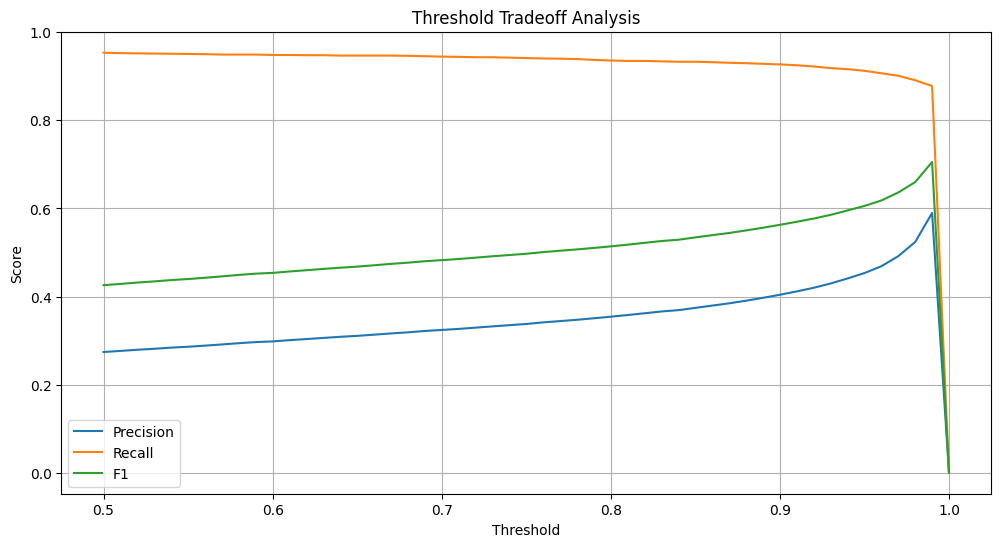

time: 232 ms (started: 2026-06-13 07:53:57 +00:00)


In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    label="F1"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tradeoff Analysis")
plt.legend()
plt.grid(True)

plt.show()

## Add Predictions Back to Original Test Rows

This joins the inference output with the original raw transaction rows.

This is useful for analyzing which transactions were flagged as fraud.

In [28]:
test_results_with_raw_data = pd.concat(
    [
        test_df.reset_index(drop=True),
        test_predictions.reset_index(drop=True)
    ],
    axis=1
)

print("Combined results shape:", test_results_with_raw_data.shape)

test_results_with_raw_data.head()

Combined results shape: (555719, 33)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,rf_prob,lgbm_prob,cat_prob,xgb_prob,nn_prob,stacking_prob,fraud_probability_percent,threshold_used,final_prediction,final_label
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,0.0,0.000360,0.000317,0.000304,0.020924,0.013755,1.3755,0.65,0,Legitimate
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,0.0,0.001150,0.001293,0.007654,0.020367,0.014044,1.4044,0.65,0,Legitimate
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,0.0,0.000143,0.000918,0.000497,0.014734,0.013724,1.3724,0.65,0,Legitimate
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,0.0,0.000085,0.000151,0.000329,0.002326,0.013538,1.3538,0.65,0,Legitimate
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,0.0,0.000460,0.001691,0.001084,0.023547,0.013901,1.3901,0.65,0,Legitimate


time: 198 ms (started: 2026-06-13 07:53:58 +00:00)


## Inspect Final Fraud Alerts

This cell shows the transactions that were flagged as fraud using the production threshold.

In [29]:
fraud_alerts = test_results_with_raw_data[
    test_results_with_raw_data["final_prediction"] == 1
].copy()

print("Number of production fraud alerts:", len(fraud_alerts))

fraud_alerts.head(20)

Number of production fraud alerts: 6538


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,rf_prob,lgbm_prob,cat_prob,xgb_prob,nn_prob,stacking_prob,fraud_probability_percent,threshold_used,final_prediction,final_label
720,720,2020-06-21 16:18:24,343472729187663,"fraud_Little, Gutmann and Lynch",shopping_net,705.59,Gloria,Wallace,F,234 Bridges Wells Apt. 389,...,0.151613,0.929177,0.917919,0.943812,0.961628,0.999021,99.9021,0.65,1,Fraud
728,728,2020-06-21 16:22:15,3518234918950662,"fraud_Gottlieb, Considine and Schultz",shopping_net,724.14,Barbara,Lowe,F,67210 Lori Creek,...,0.091378,0.221810,0.721240,0.774785,0.966782,0.919815,91.9815,0.65,1,Fraud
1044,1044,2020-06-21 18:08:47,4302480582202074,"fraud_Towne, Greenholt and Koepp",shopping_net,981.92,David,Rodriguez,M,821 Solis Points,...,0.323173,0.571166,0.862421,0.688852,0.992100,0.989429,98.9429,0.65,1,Fraud
1398,1398,2020-06-21 20:15:59,4956828990005111019,fraud_Kassulke PLC,shopping_net,1420.90,Kenneth,Robinson,M,269 Sanchez Rapids,...,0.000000,0.624950,0.896932,0.745436,0.974652,0.994187,99.4187,0.65,1,Fraud
1428,1428,2020-06-21 20:31:19,5540636818935089,fraud_Volkman-Predovic,shopping_net,2271.66,Kenneth,Foster,M,329 Michael Extension,...,0.019970,0.650096,0.906096,0.735223,0.011638,0.989550,98.9550,0.65,1,Fraud
1463,1463,2020-06-21 20:40:19,630424987505,fraud_Ernser-Lynch,food_dining,129.55,Jennifer,Black,F,2870 Bean Terrace Apt. 756,...,0.011932,0.622994,0.605339,0.657125,0.388687,0.955046,95.5046,0.65,1,Fraud
1567,1567,2020-06-21 21:15:11,6011367958204270,fraud_Connelly-Carter,home,240.96,Tammy,Ayers,F,1652 James Mews,...,0.027605,0.510913,0.655214,0.320145,0.860561,0.927734,92.7734,0.65,1,Fraud
1586,1586,2020-06-21 21:22:54,213178765398315,fraud_Jast-McDermott,shopping_pos,707.55,Alan,Colon,M,748 Bryan Fields Suite 935,...,0.107532,0.650252,0.834065,0.857621,0.967847,0.993946,99.3946,0.65,1,Fraud
1681,1681,2020-06-21 22:04:05,3583793405872580,fraud_Schmeler-Howe,personal_care,49.43,Beth,Lambert,F,6447 Johnson Estates Apt. 986,...,0.063758,0.850461,0.544807,0.758835,0.404414,0.981317,98.1317,0.65,1,Fraud
1687,1687,2020-06-21 22:07:34,4560004149983868183,"fraud_Baumbach, Hodkiewicz and Walsh",shopping_pos,661.50,Stacy,Villegas,F,20581 Pena Walks,...,0.079653,0.190155,0.869387,0.327647,0.908951,0.901215,90.1215,0.65,1,Fraud


time: 35.6 ms (started: 2026-06-13 07:53:58 +00:00)


In [30]:
fraud_alerts_path = os.path.join(
    OUTPUT_DIR,
    "production_fraud_alerts.csv"
)

fraud_alerts.to_csv(
    fraud_alerts_path,
    index=False
)

print("Saved fraud alerts to:")
print(fraud_alerts_path)

Saved fraud alerts to:
/content/fraud_stacking_inference_outputs/production_fraud_alerts.csv
time: 164 ms (started: 2026-06-13 07:53:58 +00:00)


## Confusion Matrix Visualization

This section visualizes the confusion matrices for:

1. Threshold 0.5
2. Production threshold

This helps us clearly see how many fraud cases were caught, missed, and how many false alarms were created.

In [31]:
def plot_confusion_matrix_for_threshold(
    y_true,
    y_prob,
    threshold,
    title
):
    y_pred = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=LABELS
    )

    disp.plot(
        values_format="d",
        cmap="Blues"
    )

    plt.title(title)
    plt.grid(False)
    plt.show()

    print("TN:", cm[0, 0])
    print("FP:", cm[0, 1])
    print("FN:", cm[1, 0])
    print("TP:", cm[1, 1])

time: 798 µs (started: 2026-06-13 07:53:58 +00:00)


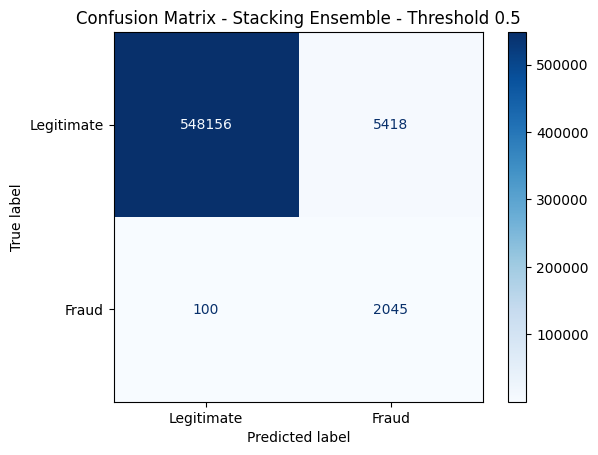

TN: 548156
FP: 5418
FN: 100
TP: 2045
time: 151 ms (started: 2026-06-13 07:53:58 +00:00)


In [32]:
plot_confusion_matrix_for_threshold(
    y_true=y_true,
    y_prob=y_prob,
    threshold=0.5,
    title="Confusion Matrix - Stacking Ensemble - Threshold 0.5"
)

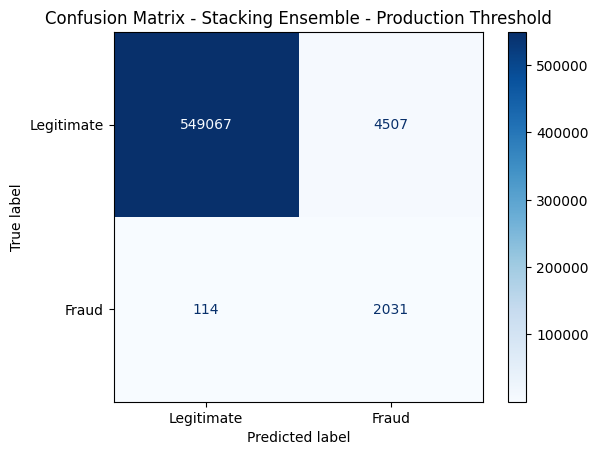

TN: 549067
FP: 4507
FN: 114
TP: 2031
Threshold: 0.65
time: 137 ms (started: 2026-06-13 07:53:58 +00:00)


In [33]:
plot_confusion_matrix_for_threshold(
    y_true=y_true,
    y_prob=y_prob,
    threshold=production_threshold,
    title="Confusion Matrix - Stacking Ensemble - Production Threshold"
)
print("Threshold:", production_threshold)

# Random Transaction Inference Demo

This section randomly selects one transaction from the test dataset and runs the full stacking inference pipeline on it.

For the selected transaction, we display:

- Original transaction details
- True label, if available
- Base model fraud probabilities
- Stacking fraud probability
- Production threshold
- Final prediction
- Whether the prediction was correct

In [34]:
def run_random_transaction_demo(data_df, threshold=None):
    if threshold is None:
        threshold = production_threshold

    random_index = np.random.choice(data_df.index)

    transaction_df = data_df.loc[[random_index]].copy()

    prediction_df = predict_fraud_stacking(
        transaction_df,
        threshold=threshold
    )

    transaction_info_cols = [
        "trans_date_trans_time",
        "merchant",
        "category",
        "amt",
        "gender",
        "city",
        "state",
        "job",
        "lat",
        "long",
        "merch_lat",
        "merch_long",
    ]

    available_info_cols = [
        col for col in transaction_info_cols
        if col in transaction_df.columns
    ]

    print("=" * 90)
    print("RANDOM TRANSACTION SELECTED")
    print("=" * 90)

    print("Dataset index:", random_index)

    if "is_fraud" in transaction_df.columns:
        true_label_num = int(transaction_df["is_fraud"].iloc[0])
        true_label_text = "Fraud" if true_label_num == 1 else "Legitimate"

        print("True Label:", true_label_text)
        print("True Label Value:", true_label_num)

    print("\nTransaction Details:")
    display(transaction_df[available_info_cols].T.rename(columns={random_index: "Value"}))

    print("\nModel Prediction Details:")
    display(prediction_df.T.rename(columns={0: "Value"}))

    stacking_prob = float(prediction_df["stacking_prob"].iloc[0])
    final_prediction = int(prediction_df["final_prediction"].iloc[0])
    final_label = prediction_df["final_label"].iloc[0]
    threshold_used = float(prediction_df["threshold_used"].iloc[0])

    print("=" * 90)
    print("FINAL DECISION")
    print("=" * 90)

    print("Stacking Fraud Probability:", round(stacking_prob, 8))
    print("Fraud Probability Percent:", round(stacking_prob * 100, 4), "%")
    print("Threshold Used:", threshold_used)
    print("Final Prediction:", final_prediction)
    print("Final Label:", final_label)

    if "is_fraud" in transaction_df.columns:
        is_correct = final_prediction == true_label_num

        print("\nPrediction Correct:", is_correct)

        if is_correct:
            print("Result: Correct classification")
        else:
            print("Result: Wrong classification")

    return transaction_df, prediction_df

time: 2.37 ms (started: 2026-06-13 07:53:58 +00:00)


In [47]:
random_transaction, random_prediction = run_random_transaction_demo(
    test_df,
    threshold=production_threshold
)

RANDOM TRANSACTION SELECTED
Dataset index: 421909
True Label: Legitimate
True Label Value: 0

Transaction Details:


,Value
trans_date_trans_time,2020-12-01 22:33:36
merchant,fraud_Baumbach Ltd
category,personal_care
amt,9.0
gender,F
city,Lowell
state,OR
job,Systems analyst
lat,43.921
long,-122.7806



Model Prediction Details:


,Value
rf_prob,0.0
lgbm_prob,0.005369
cat_prob,0.011088
xgb_prob,0.059768
nn_prob,0.554177
stacking_prob,0.02444
fraud_probability_percent,2.444
threshold_used,0.65
final_prediction,0
final_label,Legitimate


FINAL DECISION
Stacking Fraud Probability: 0.0244395
Fraud Probability Percent: 2.444 %
Threshold Used: 0.65
Final Prediction: 0
Final Label: Legitimate

Prediction Correct: True
Result: Correct classification
time: 371 ms (started: 2026-06-13 08:06:40 +00:00)


# Prediction Case Study Explorer

This section helps us understand the behavior of the stacking ensemble by sampling one transaction from each prediction type:

- True Negative: legitimate transaction correctly approved
- True Positive: fraud transaction correctly flagged
- False Positive: legitimate transaction incorrectly flagged
- False Negative: fraud transaction incorrectly approved

This is useful for explaining model behavior and understanding business tradeoffs.

In [48]:
def build_case_study_dataset(raw_df, predictions_df):
    case_df = pd.concat(
        [
            raw_df.reset_index(drop=True),
            predictions_df.reset_index(drop=True)
        ],
        axis=1
    )

    if "is_fraud" not in case_df.columns:
        raise ValueError("The raw dataframe must contain 'is_fraud' for case study analysis.")

    case_df["true_label"] = case_df["is_fraud"].astype(int)
    case_df["predicted_label"] = case_df["final_prediction"].astype(int)

    case_df["prediction_case"] = np.select(
        [
            (case_df["true_label"] == 0) & (case_df["predicted_label"] == 0),
            (case_df["true_label"] == 1) & (case_df["predicted_label"] == 1),
            (case_df["true_label"] == 0) & (case_df["predicted_label"] == 1),
            (case_df["true_label"] == 1) & (case_df["predicted_label"] == 0),
        ],
        [
            "True Negative",
            "True Positive",
            "False Positive",
            "False Negative",
        ],
        default="Unknown"
    )

    return case_df

time: 1.11 ms (started: 2026-06-13 08:08:25 +00:00)


In [49]:
def display_prediction_case(case_df, case_name):
    selected_cases = case_df[
        case_df["prediction_case"] == case_name
    ]

    if len(selected_cases) == 0:
        print(f"No cases found for: {case_name}")
        return None

    selected_row = selected_cases.sample(
        n=1
    ).iloc[0]

    selected_index = selected_row.name

    raw_transaction = test_df.loc[[selected_index]].copy()

    prediction_columns = [
        "rf_prob",
        "lgbm_prob",
        "cat_prob",
        "xgb_prob",
        "nn_prob",
        "stacking_prob",
        "fraud_probability_percent",
        "threshold_used",
        "final_prediction",
        "final_label",
    ]

    transaction_columns = [
        "trans_date_trans_time",
        "merchant",
        "category",
        "amt",
        "gender",
        "city",
        "state",
        "job",
        "lat",
        "long",
        "merch_lat",
        "merch_long",
        "is_fraud",
    ]

    available_transaction_columns = [
        col for col in transaction_columns
        if col in case_df.columns
    ]

    print("=" * 90)
    print(case_name.upper())
    print("=" * 90)

    print("Dataset index:", selected_index)
    print("True Label:", "Fraud" if int(selected_row["true_label"]) == 1 else "Legitimate")
    print("Predicted Label:", selected_row["final_label"])

    print("\nTransaction Details:")
    display(
        selected_row[available_transaction_columns]
        .to_frame(name="Value")
    )

    print("\nModel Prediction Details:")
    display(
        selected_row[prediction_columns]
        .to_frame(name="Value")
    )

    print("\nBusiness Interpretation:")

    if case_name == "True Negative":
        print("The transaction was legitimate and the model correctly approved it.")

    elif case_name == "True Positive":
        print("The transaction was fraud and the model correctly flagged it for verification or blocking.")

    elif case_name == "False Positive":
        print("The transaction was legitimate but the model flagged it as suspicious.")
        print("This is why the system should use step-up verification instead of automatic rejection.")

    elif case_name == "False Negative":
        print("The transaction was fraud but the model approved it.")
        print("These cases are important for future error analysis and model improvement.")

    return selected_row

time: 2.24 ms (started: 2026-06-13 08:08:25 +00:00)


In [ ]:
case_study_df = build_case_study_dataset(
    test_df,
    test_predictions
)

In [51]:
true_negative_case = display_prediction_case(
    case_study_df,
    "True Negative"
)

TRUE NEGATIVE
Dataset index: 328645
True Label: Legitimate
Predicted Label: Legitimate

Transaction Details:


,Value
trans_date_trans_time,2020-10-25 12:40:39
merchant,fraud_Kozey-Kuhlman
category,personal_care
amt,14.17
gender,F
city,Sebring
state,FL
job,Environmental consultant
lat,27.4703
long,-81.4872



Model Prediction Details:


,Value
rf_prob,0.0
lgbm_prob,0.002155
cat_prob,0.001609
xgb_prob,0.009858
nn_prob,0.069874
stacking_prob,0.014717
fraud_probability_percent,1.4717
threshold_used,0.65
final_prediction,0
final_label,Legitimate



Business Interpretation:
The transaction was legitimate and the model correctly approved it.
time: 503 ms (started: 2026-06-13 08:08:47 +00:00)


In [52]:
true_positive_case = display_prediction_case(
    case_study_df,
    "True Positive"
)

TRUE POSITIVE
Dataset index: 29859
True Label: Fraud
Predicted Label: Fraud

Transaction Details:


,Value
trans_date_trans_time,2020-06-30 23:04:32
merchant,"fraud_Gottlieb, Considine and Schultz"
category,shopping_net
amt,993.55
gender,F
city,Louisville
state,KY
job,Engineering geologist
lat,38.2507
long,-85.7476



Model Prediction Details:


,Value
rf_prob,0.975909
lgbm_prob,0.999784
cat_prob,0.999719
xgb_prob,0.999697
nn_prob,0.997432
stacking_prob,0.99947
fraud_probability_percent,99.947
threshold_used,0.65
final_prediction,1
final_label,Fraud



Business Interpretation:
The transaction was fraud and the model correctly flagged it for verification or blocking.
time: 63.7 ms (started: 2026-06-13 08:09:09 +00:00)


In [53]:
false_positive_case = display_prediction_case(
    case_study_df,
    "False Positive"
)

FALSE POSITIVE
Dataset index: 239858
True Label: Legitimate
Predicted Label: Fraud

Transaction Details:


,Value
trans_date_trans_time,2020-09-15 17:12:25
merchant,"fraud_Willms, Kris and Bergnaum"
category,shopping_pos
amt,1594.41
gender,M
city,Conway
state,NH
job,Surgeon
lat,43.9742
long,-71.1503



Model Prediction Details:


,Value
rf_prob,0.015929
lgbm_prob,0.190393
cat_prob,0.93573
xgb_prob,0.901197
nn_prob,0.611629
stacking_prob,0.966416
fraud_probability_percent,96.6416
threshold_used,0.65
final_prediction,1
final_label,Fraud



Business Interpretation:
The transaction was legitimate but the model flagged it as suspicious.
This is why the system should use step-up verification instead of automatic rejection.
time: 68.3 ms (started: 2026-06-13 08:09:18 +00:00)


In [54]:
false_negative_case = display_prediction_case(
    case_study_df,
    "False Negative"
)

FALSE NEGATIVE
Dataset index: 511374
True Label: Fraud
Predicted Label: Legitimate

Transaction Details:


,Value
trans_date_trans_time,2020-12-21 22:59:22
merchant,fraud_Botsford and Sons
category,home
amt,219.11
gender,F
city,Heart Butte
state,MT
job,Water engineer
lat,48.2777
long,-112.8456



Model Prediction Details:


,Value
rf_prob,0.055783
lgbm_prob,0.128102
cat_prob,0.547155
xgb_prob,0.520989
nn_prob,0.574852
stacking_prob,0.598205
fraud_probability_percent,59.8205
threshold_used,0.65
final_prediction,0
final_label,Legitimate



Business Interpretation:
The transaction was fraud but the model approved it.
These cases are important for future error analysis and model improvement.
time: 58.8 ms (started: 2026-06-13 08:09:38 +00:00)


# Notebook Summary

This notebook performs production inference for the Fraud Detection Stacking Ensemble.

Pipeline:

1. Load saved artifacts using gdown.
2. Recreate training feature engineering.
3. Apply saved preprocessing.
4. Generate probabilities from:
   - Random Forest
   - LightGBM
   - CatBoost
   - XGBoost
   - Neural Network
5. Build meta-features:
   - rf_prob
   - lgbm_prob
   - cat_prob
   - xgb_prob
   - nn_prob
6. Generate stacking probability using Logistic Regression.
7. Apply the production threshold selected from OOF predictions.
8. Return final fraud predictions.
9. Evaluate the model on the full Kaggle test set.
10. Save full predictions, evaluation summary, and production fraud alerts.

No model training occurs in this notebook.

All predictions are generated using the saved production artifacts.